In [1]:
# Imports, setup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# 3 method families
info_methods = [
    'MSP', 'PPL', 'MTE', 'TokenSAR'
]

consistency_methods = [
    'NumSemSets', 'DegMat_NLI_score_entail', 'DegMat_NLI_score_contra', 
    'DegMat_Jaccard_score', 'EigValLaplacian_NLI_score_entail', 
    'EigValLaplacian_NLI_score_contra', 'EigValLaplacian_Jaccard_score', 
    'Eccentricity_NLI_score_entail', 'Eccentricity_NLI_score_contra',
    'Eccentricity_Jaccard_score', 'LexicalSimilarity_rouge1', 
    'LexicalSimilarity_rouge2', 'LS_rL', 'LexicalSimilarity_BLEU'
]

# LS_rL is LexicalSimilarity_rougeL

hybrid_methods = [
    'SentenceSAR', 'SAR', 'SE'
]
# SE is Semantic Entropy

# Create a dictionary to map each method to its color
color_map = {}
for method in info_methods:
    color_map[method] = 'cornflowerblue' # Blue for Information-Theoretic
for method in consistency_methods:
    color_map[method] = 'mediumseagreen'   # Green for Consistency-Based
for method in hybrid_methods:
    color_map[method] = 'salmon'         # Red/Orange for Hybrid

## TESTING: gemma_medmcqa_direct.csv

In [3]:
# Load CSVs with PRR Scores
df_gemma_medmcqa_direct = pd.read_csv('gemma_medmcqa_direct.csv', index_col=0)
df_gemma_medmcqa_reasoning = pd.read_csv('gemma_medmcqa_reasoning.csv', index_col=0)

df_gemma_medmcqa_direct.head()

,r1,r2,rL,BLEU,Bert,Sbert,Accuracy,AlignScore
MSP,0.364411,NaN,0.364411,0.364411,0.310839,0.312934,0.367045,0.357672
PPL,0.364411,NaN,0.364411,0.364411,0.310839,0.312934,0.367045,0.357672
MTE,0.366909,NaN,0.366909,0.366909,0.313280,0.315377,0.369486,0.360206
TokenSAR,0.363410,NaN,0.363410,0.363410,0.309605,0.311820,0.366044,0.356770
NumSemSets,0.163987,NaN,0.163987,0.163987,0.153713,0.147812,0.163175,0.161755


In [4]:
quality_metric = 'Accuracy'

gemma_medmcqa_direct_data = df_gemma_medmcqa_direct[quality_metric]
gemma_medmcqa_reasoning_data = df_gemma_medmcqa_reasoning[quality_metric]
diff_data = gemma_medmcqa_reasoning_data - gemma_medmcqa_direct_data

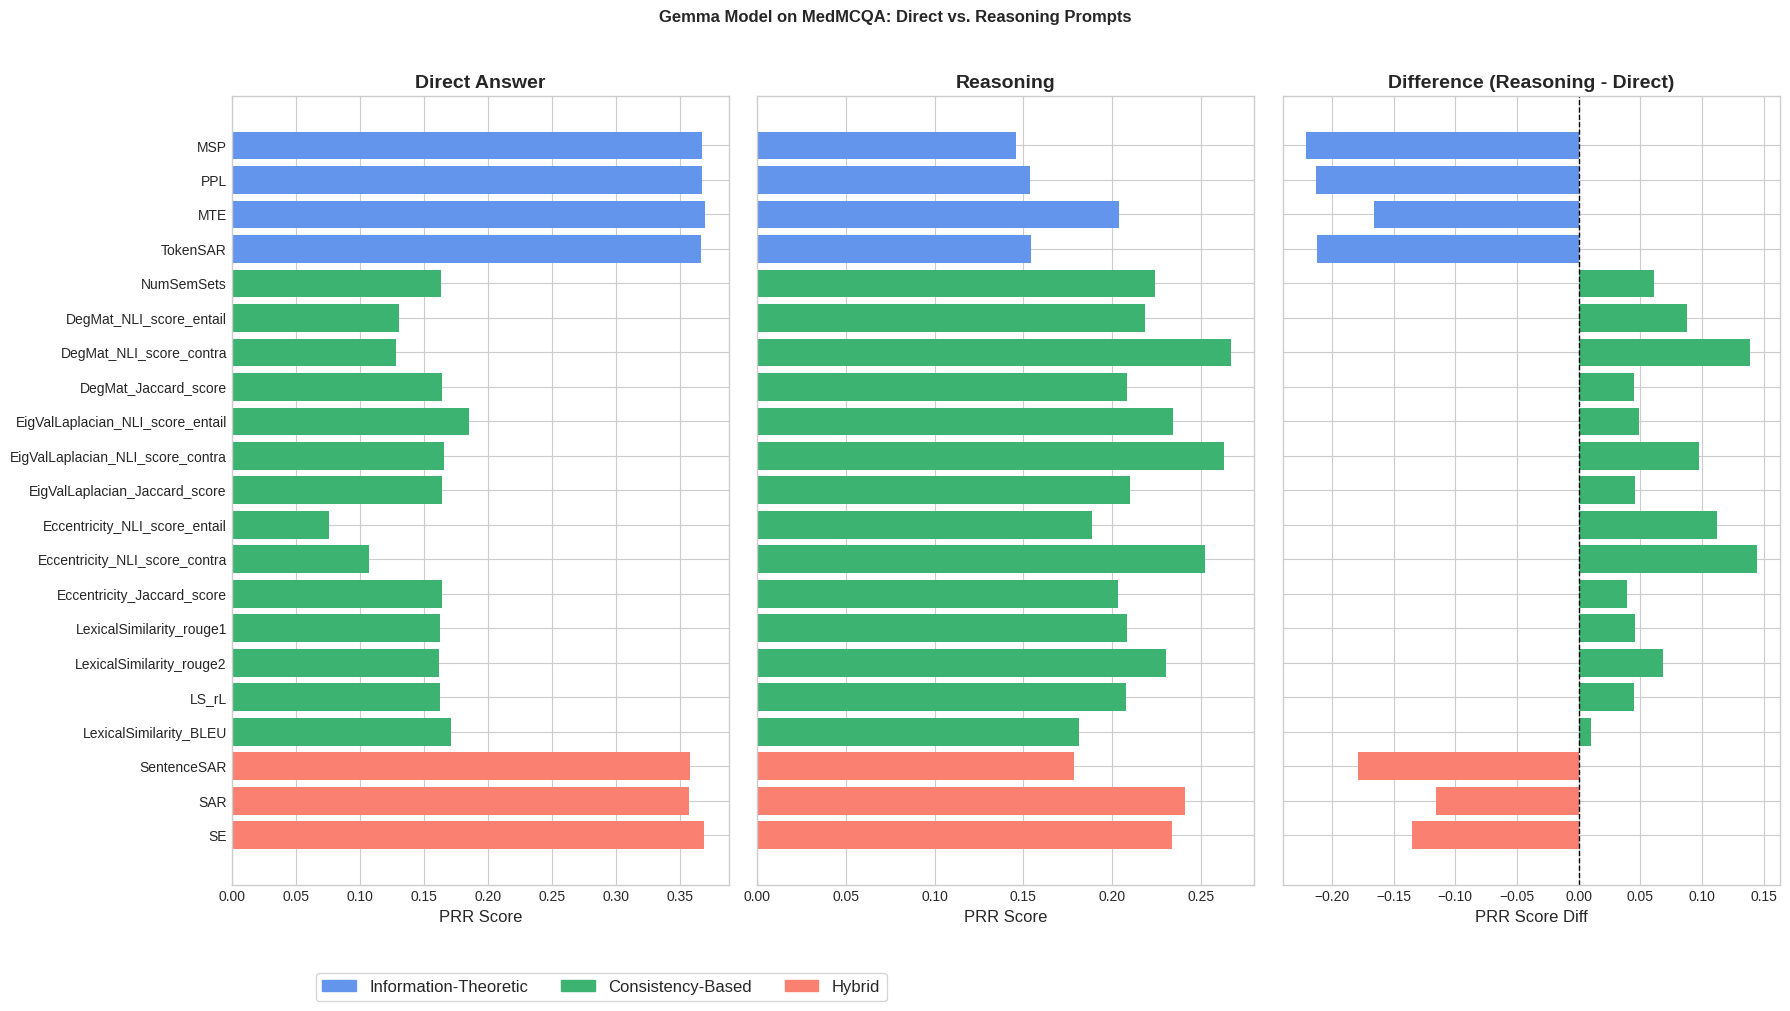

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

def create_bar_chart(ax, data, title, xlabel):
    bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_ylabel('')
    ax.invert_yaxis()

# Plot 1: Direct
create_bar_chart(axes[0], gemma_medmcqa_direct_data, 'Direct Answer', f'PRR Score')

# Plot 2: Reasoning
create_bar_chart(axes[1], gemma_medmcqa_reasoning_data, 'Reasoning', f'PRR Score')

# Plot 3: Difference
create_bar_chart(axes[2], diff_data, 'Difference (Reasoning - Direct)', 'PRR Score Diff')
# Add a vertical line at zero to easily see improvements vs. regressions
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

legend_patches = [
    mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
    mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
    mpatches.Patch(color='salmon', label='Hybrid')
]


fig.legend(handles=legend_patches, loc='lower right', 
            bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=12)

fig.suptitle('Gemma Model on MedMCQA: Direct vs. Reasoning Prompts', fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()

# bars = ax.barh(gemma_medmcqa_direct_data.index, gemma_medmcqa_direct_data.values)

# ax.set_xlabel('PRR Score', fontsize=12)
# ax.set_ylabel('')
# ax.set_title('gemma medmcqa-direct', fontsize=14, fontweight='bold')

# # This is stupid but I don't care
# bar_colors = [color_map[method] for method, _ in gemma_medmcqa_direct_data.items()]

# for idx, bar in enumerate(bars):
#     bar.set_color(bar_colors[idx])


# ax.legend(handles=legend_patches, loc='lower right', fontsize=11)

# plt.tight_layout()
# plt.show()

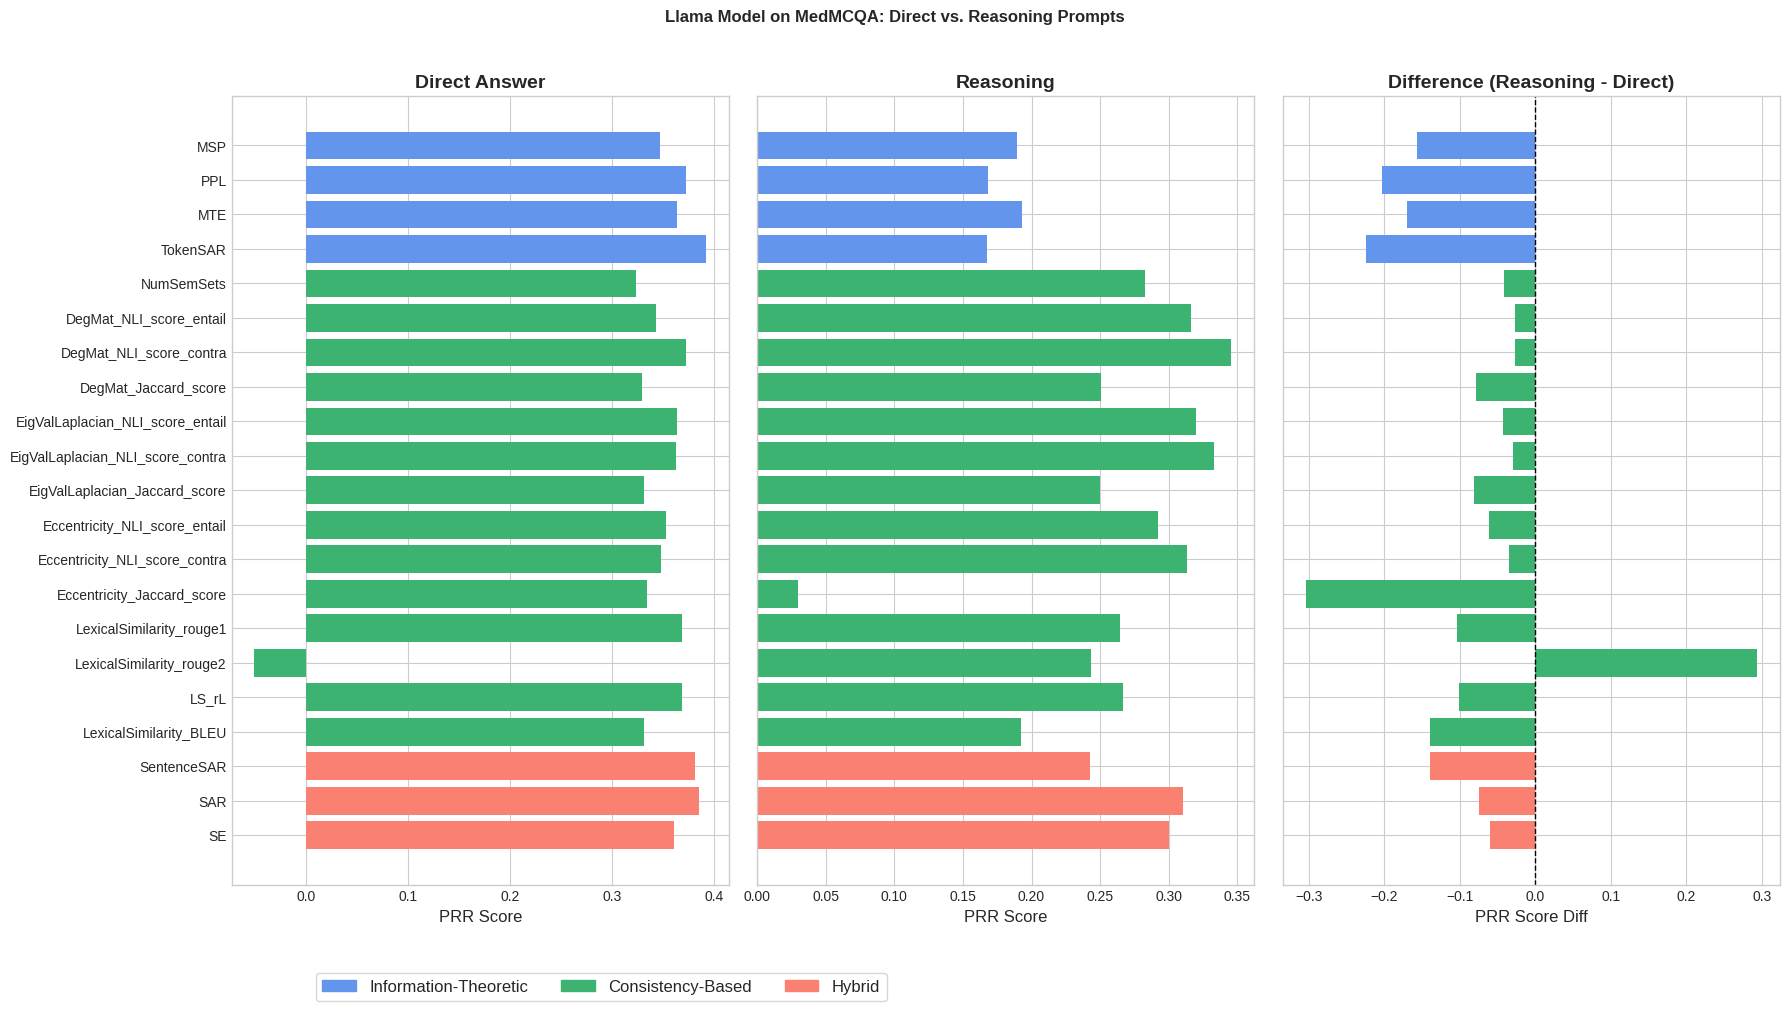

In [6]:
# Load CSVs with PRR Scores
df_llama_medmcqa_direct = pd.read_csv('llama_medmcqa_direct.csv', index_col=0)
df_llama_medmcqa_reasoning = pd.read_csv('llama_medmcqa_reasoning.csv', index_col=0)

df_llama_medmcqa_direct.head()
llama_medmcqa_direct_data = df_llama_medmcqa_direct[quality_metric]
llama_medmcqa_reasoning_data = df_llama_medmcqa_reasoning[quality_metric]
diff_data = llama_medmcqa_reasoning_data - llama_medmcqa_direct_data

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

def create_bar_chart(ax, data, title, xlabel):
    bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index]) 
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_ylabel('')
    ax.invert_yaxis()

# Plot 1: Direct
create_bar_chart(axes[0], llama_medmcqa_direct_data, 'Direct Answer', f'PRR Score')

# Plot 2: Reasoning
create_bar_chart(axes[1], llama_medmcqa_reasoning_data, 'Reasoning', f'PRR Score')

# Plot 3: Difference
create_bar_chart(axes[2], diff_data, 'Difference (Reasoning - Direct)', 'PRR Score Diff')
# Add a vertical line at zero to easily see improvements vs. regressions
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

legend_patches = [
    mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
    mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
    mpatches.Patch(color='salmon', label='Hybrid')
]


fig.legend(handles=legend_patches, loc='lower right', 
            bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=12)

fig.suptitle('Llama Model on MedMCQA: Direct vs. Reasoning Prompts', fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()


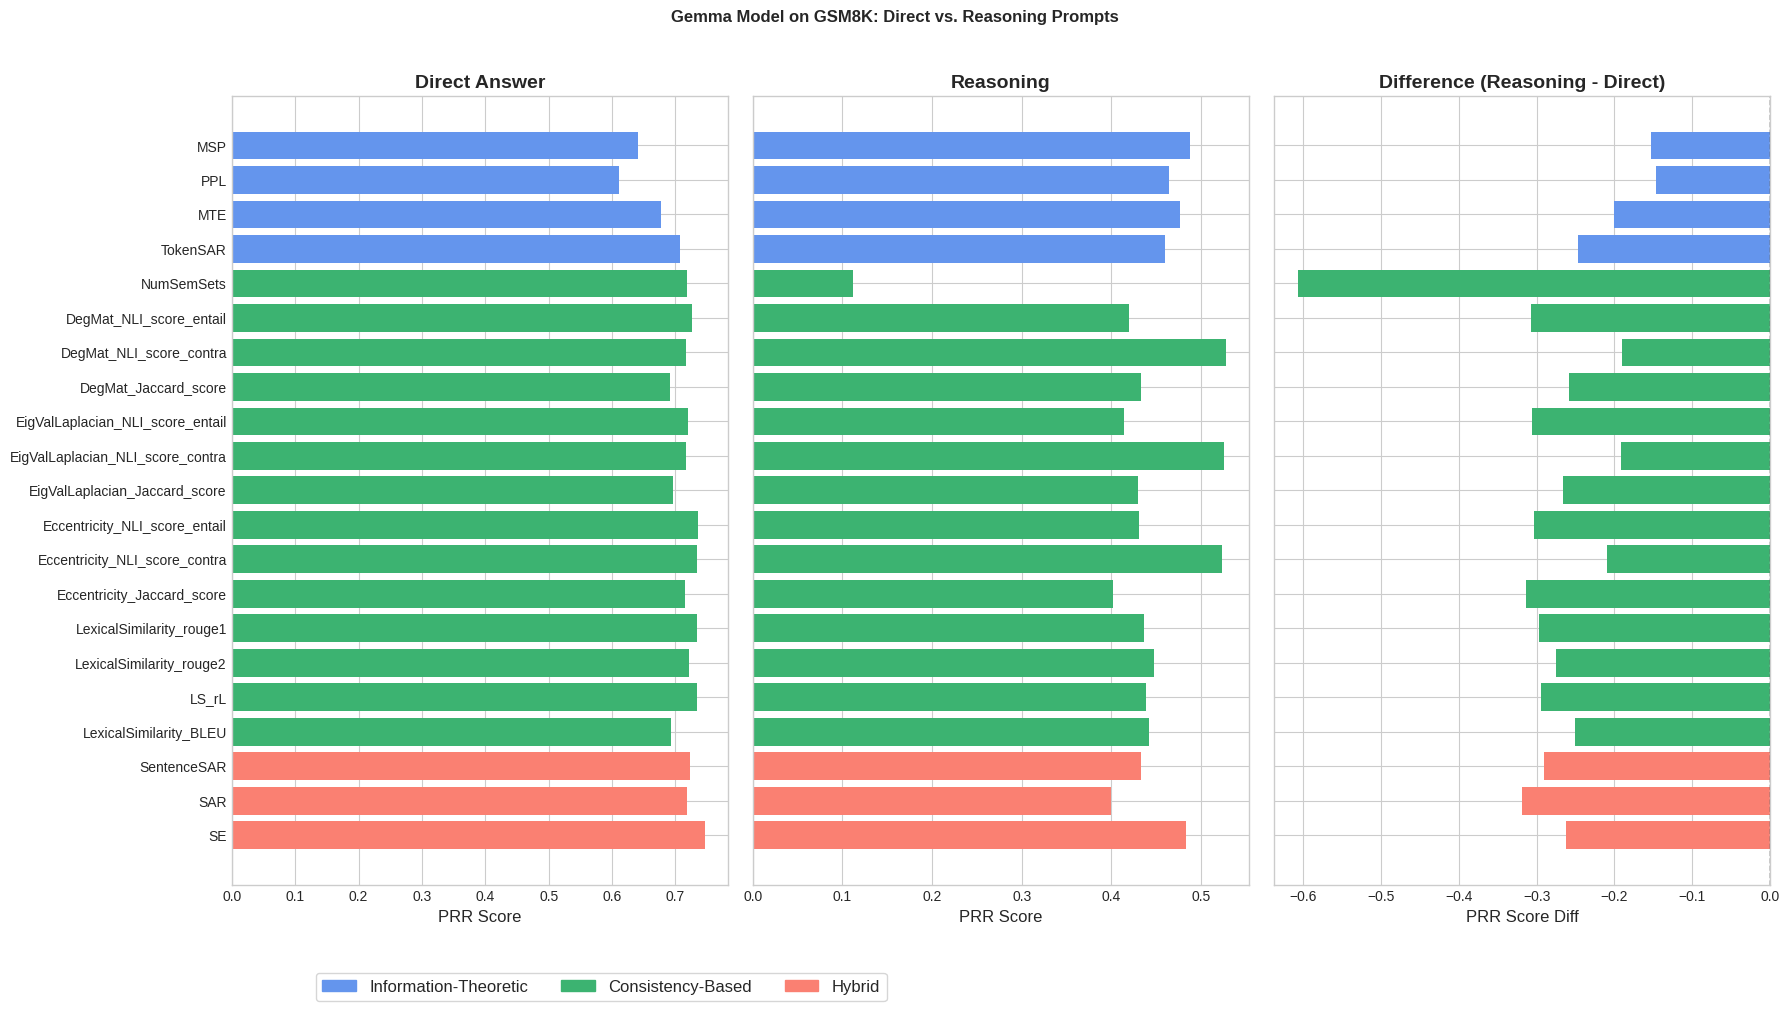

In [7]:
# Load CSVs with PRR Scores
df_gemma_gsm8k_direct = pd.read_csv('gemma_gsm8k_direct.csv', index_col=0)
df_gemma_gsm8k_reasoning = pd.read_csv('gemma_gsm8k_reasoning.csv', index_col=0)

df_gemma_gsm8k_direct.head()
gemma_gsm8k_direct_data = df_gemma_gsm8k_direct[quality_metric]
gemma_gsm8k_reasoning_data = df_gemma_gsm8k_reasoning[quality_metric]
diff_data = gemma_gsm8k_reasoning_data - gemma_gsm8k_direct_data

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)

def create_bar_chart(ax, data, title, xlabel):
    bars = ax.barh(data.index, data.values, color=[color_map.get(method, 'grey') for method in data.index]) 
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(axis='x', labelsize=10)
    ax.set_ylabel('')
    ax.invert_yaxis()

# Plot 1: Direct
create_bar_chart(axes[0], gemma_gsm8k_direct_data, 'Direct Answer', f'PRR Score')

# Plot 2: Reasoning
create_bar_chart(axes[1], gemma_gsm8k_reasoning_data, 'Reasoning', f'PRR Score')

# Plot 3: Difference
create_bar_chart(axes[2], diff_data, 'Difference (Reasoning - Direct)', 'PRR Score Diff')
# Add a vertical line at zero to easily see improvements vs. regressions
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

legend_patches = [
    mpatches.Patch(color='cornflowerblue', label='Information-Theoretic'),
    mpatches.Patch(color='mediumseagreen', label='Consistency-Based'),
    mpatches.Patch(color='salmon', label='Hybrid')
]


fig.legend(handles=legend_patches, loc='lower right', 
            bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=12)

fig.suptitle('Gemma Model on GSM8K: Direct vs. Reasoning Prompts', fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.show()
